In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_stata('../data/renamed_rows_final.dta')
numeric_df = df.select_dtypes(include=['number'])

In [4]:
df.columns

Index(['country_code', 'year', 'electricity_access', 'borrowers', 'cpi',
       'cpia_econ_rating', 'cpia_financial_rating', 'cpia_gender_eq_rating',
       'cpia_macro_rating', 'cpia_social_inclus_rating',
       'cpia_prpty_rights_rating', 'cpia_social_protctn_rating',
       'depth_of_credit', 'dmstc_crdt_financial', 'dmstc_crdt_privt',
       'export_volume', 'informal_payments', 'cp_inflation_perc',
       'country_name', 'gdp_deflator', 'gdp_constant', 'gdp_pc_growth',
       'cpia_avg_rating'],
      dtype='object')

## Correlation Matrix

In [5]:
cov = numeric_df.cov()
corr = numeric_df.corr()

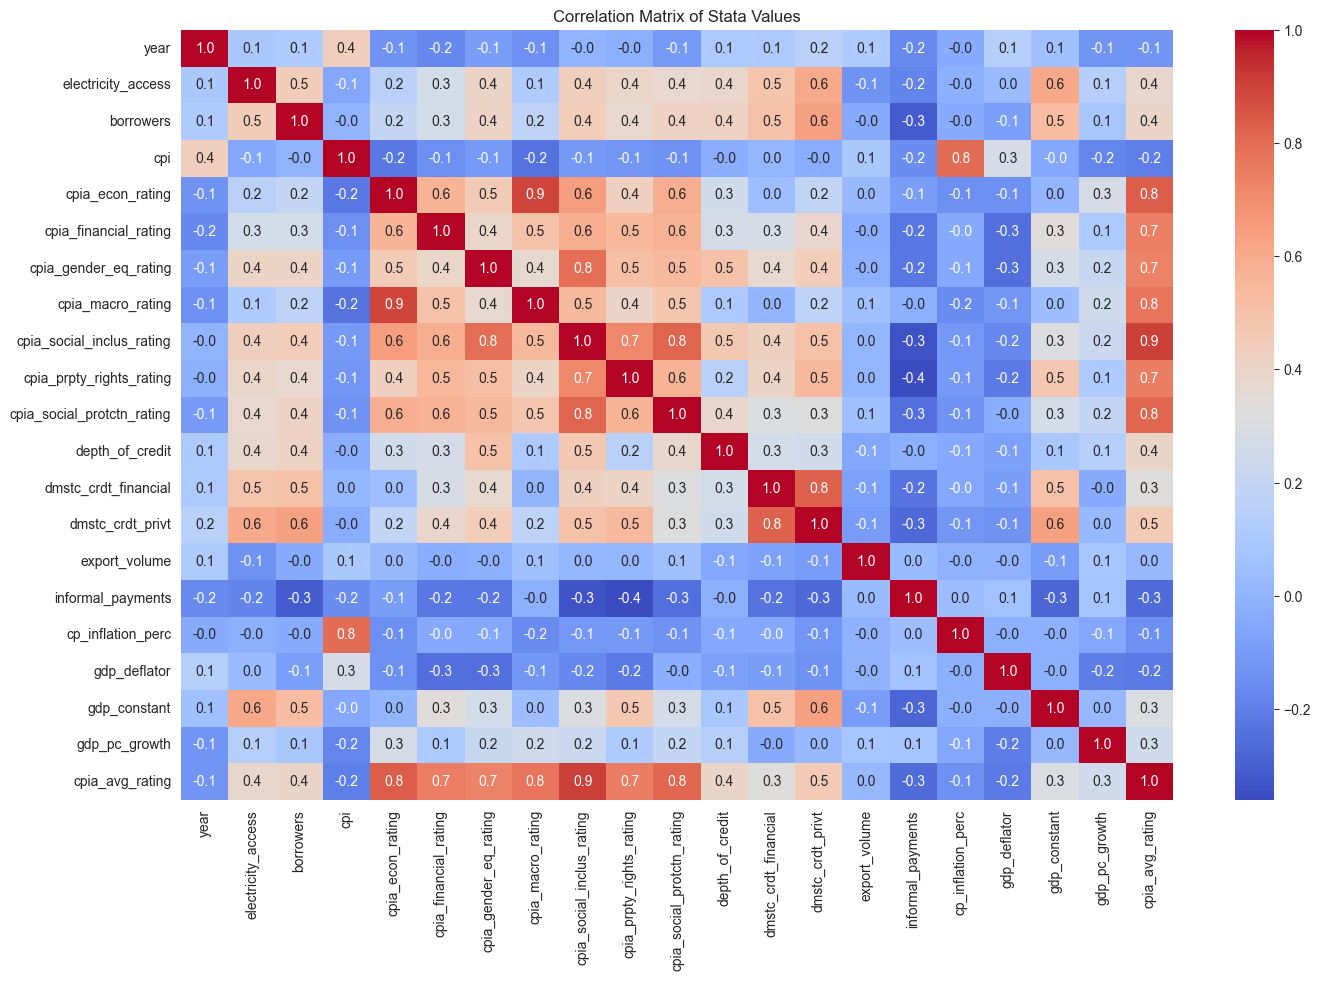

<Axes: title={'center': 'Consumer Price Index Results'}>

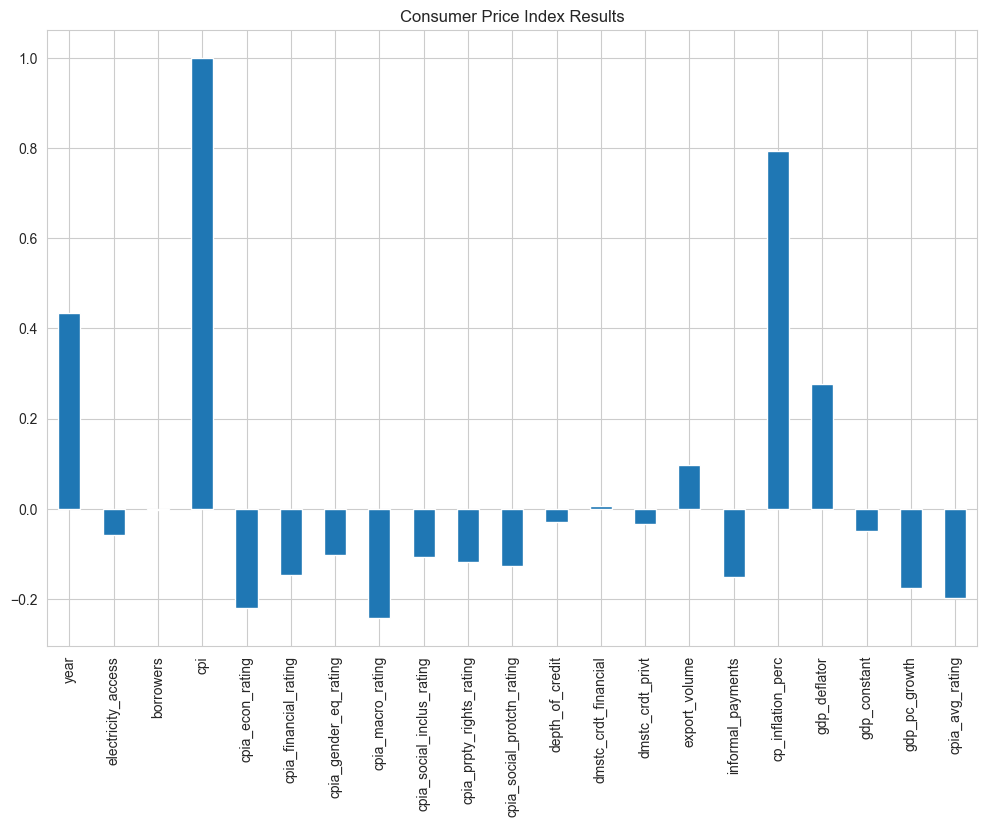

In [18]:
# Set up the figure
def heatmap(df,title,annot=True):
    plt.figure(figsize = (16, 10))
    sns.heatmap(df,annot=annot,cmap='coolwarm',fmt='.1f' if annot else '')
    plt.title(title)
    plt.show()

heatmap(corr,"Correlation Matrix of Stata Values")
corr['cpi'].plot(kind='bar',figsize=(12,8),title='Consumer Price Index Results')

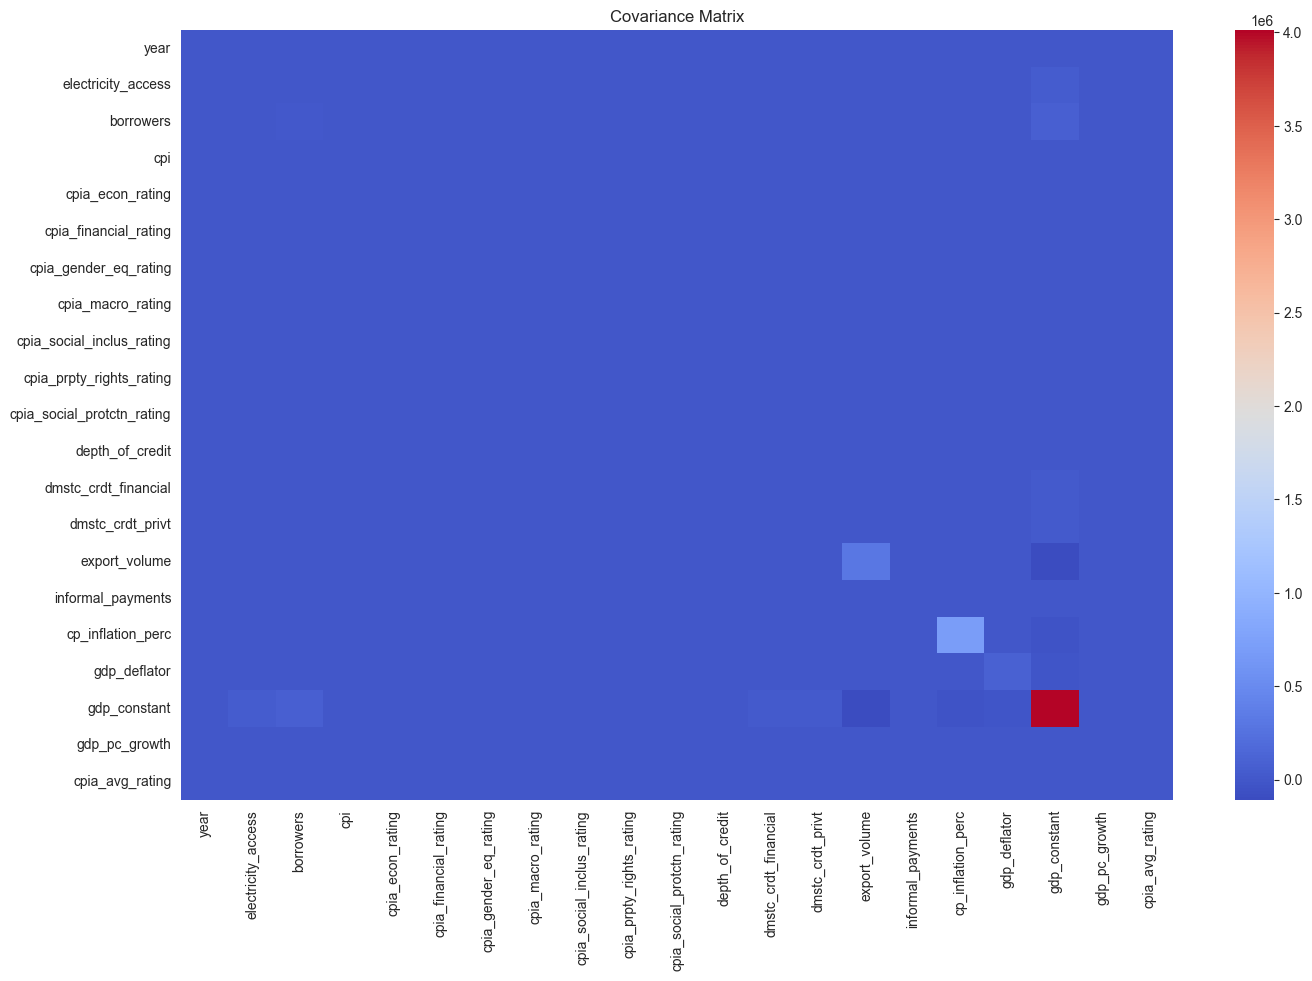

In [19]:
heatmap(cov,"Covariance Matrix",annot=False)

## Primary Variable Graphs

In [9]:
#'CPIAmacroeconomicmanagementra' 
#'Consumerpriceindex2010100'
df.rename({
    'cpia_macro_rating':'EconManagement',
    'cpi':'CPI'
    },
    axis=1,
    inplace=True)
filtered = df[df['EconManagement'] >= 2]

In [10]:
FONT_SIZE = 11

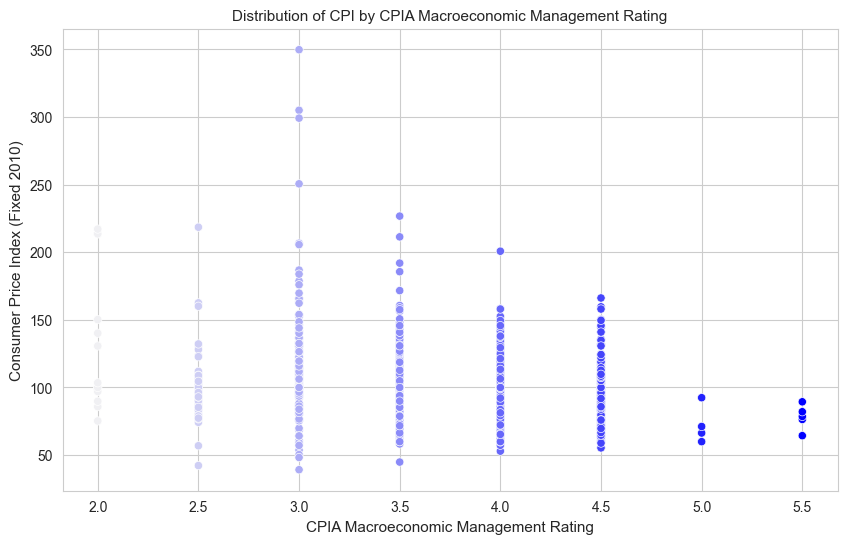

In [11]:
plt.figure(figsize=(10,6))
sns.set_palette('light:b')
sns.set_style("whitegrid")
sns.scatterplot(filtered,x='EconManagement',y='CPI',hue='EconManagement',legend=False,palette='light:b')
plt.title("Distribution of CPI by CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.xlabel("CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.ylabel("Consumer Price Index (Fixed 2010)", fontsize=FONT_SIZE)
plt.show()

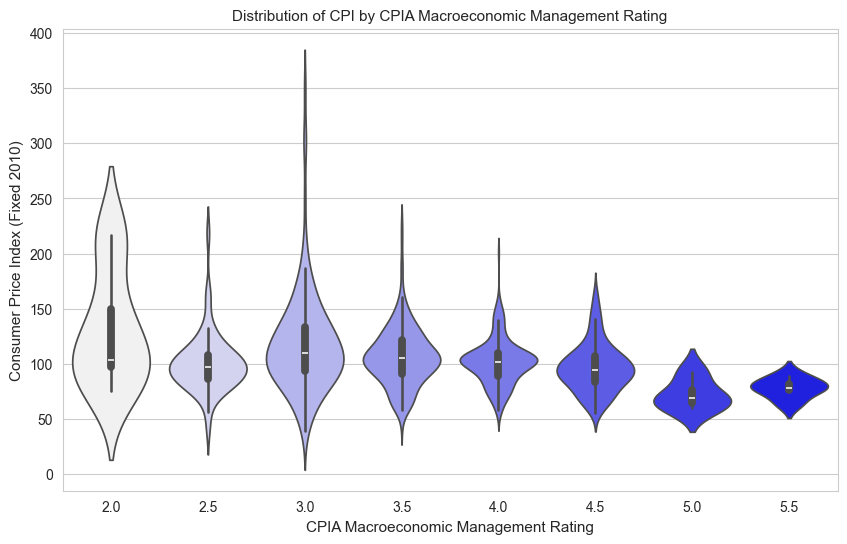

In [12]:
plt.figure(figsize=(10,6))
sns.set_palette('light:b')
sns.set_style("whitegrid")
sns.violinplot(filtered,x='EconManagement',y='CPI',hue='EconManagement',legend=False,palette='light:b')
plt.title("Distribution of CPI by CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.xlabel("CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.ylabel("Consumer Price Index (Fixed 2010)", fontsize=FONT_SIZE)
plt.show()

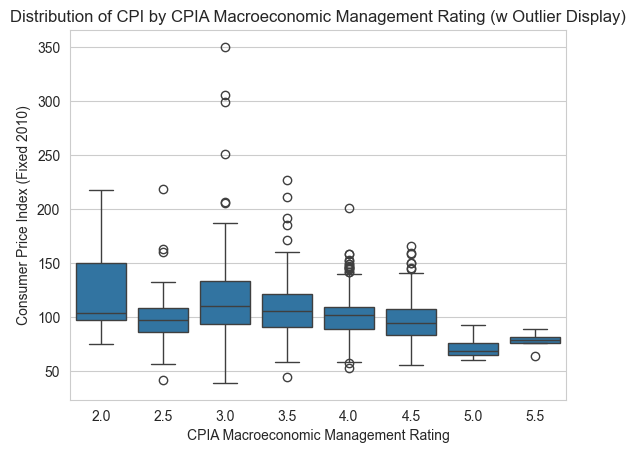

In [13]:
sns.set_palette('tab10')
sns.set_style('whitegrid')
sns.boxplot(filtered,x='EconManagement',y='CPI')


plt.title("Distribution of CPI by CPIA Macroeconomic Management Rating (w Outlier Display)")
plt.xlabel("CPIA Macroeconomic Management Rating")
plt.ylabel("Consumer Price Index (Fixed 2010)")
plt.show()

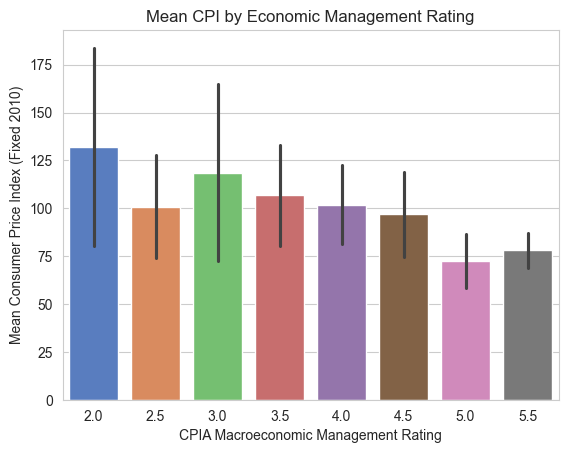

In [14]:
sns.barplot(data=filtered, 
            x='EconManagement', 
            y='CPI',
            errorbar='sd', 
            hue='EconManagement',
            palette='muted',
            legend=False)
plt.title("Mean CPI by Economic Management Rating")
plt.xlabel("CPIA Macroeconomic Management Rating")
plt.ylabel("Mean Consumer Price Index (Fixed 2010)")
plt.show()

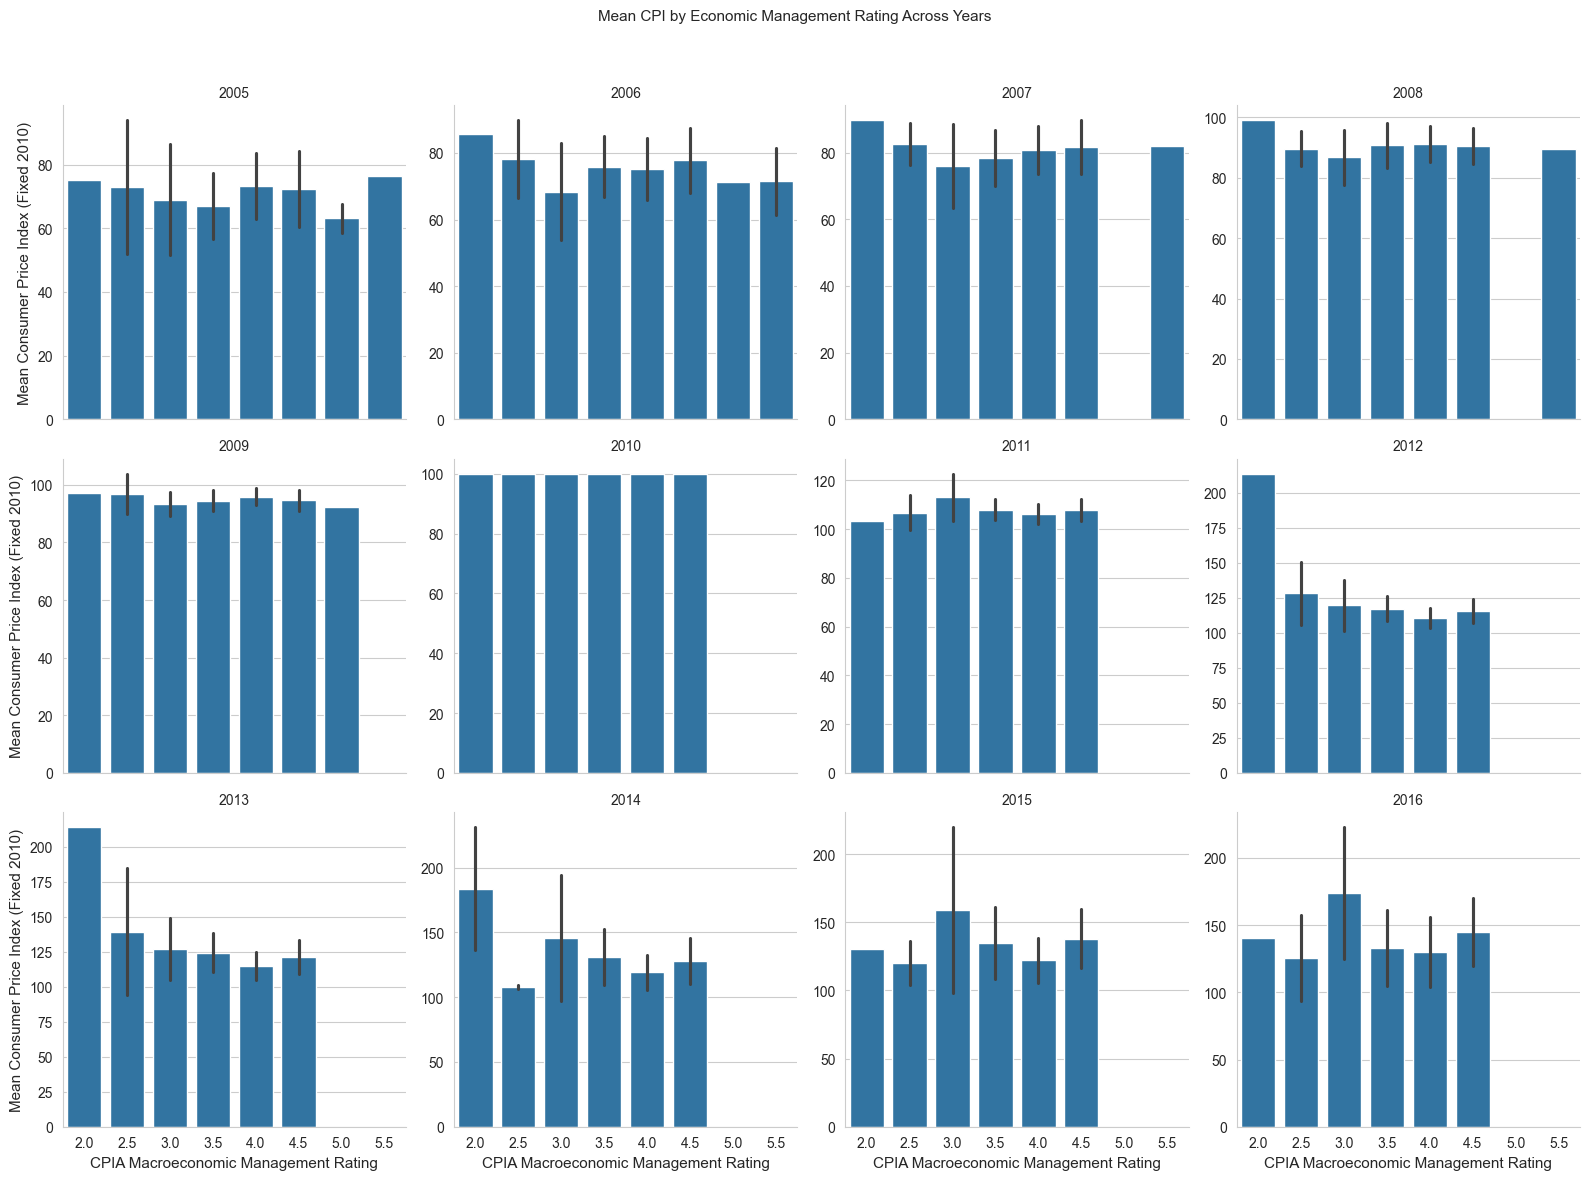

In [13]:
g = sns.FacetGrid(filtered, col="Time", col_wrap=4, height=4, sharey=False)
g.map(sns.barplot, 
      "EconManagement", 
      "CPI", 
      order=sorted(filtered['EconManagement'].unique()),
      errorbar="sd")
g.set_titles("{col_name}")
g.set_axis_labels("CPIA Macroeconomic Management Rating", "Mean Consumer Price Index (Fixed 2010)",fontsize=FONT_SIZE)
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Mean CPI by Economic Management Rating Across Years",fontsize=FONT_SIZE)
plt.show()